In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score



df = pd.read_excel('Tension Test_VIT.xlsx')

df.columns = df.columns.astype(str).str.strip()

print(f"Dataset Loaded: {df.shape[0]} experimental rows and {df.shape[1]} features.")
print("Verified Columns:", df.columns.tolist())

Dataset Loaded: 506 experimental rows and 24 features.
Verified Columns: ['Mixture', 'Specimen', 'Fiber Type', 'Fiber Volume', 'Length (mm)', 'Diameter (mm)', 'L/D', 'Shape Factor', 'RI', 'Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F', 'GGBS', 'Coarse Aggr.', 'Silica Fume', 'Water Reducer / SP', 'Fiber', 'C/B', 'W/C', 'W/B', 'Second Stress', 'Second Strain']


In [ ]:
potential_targets = [col for col in df.columns if 'strain' in col.lower()]

if potential_targets:
    target_col = potential_targets[0]
    print(f"Target variable identified as: '{target_col}'")

    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    df = df.dropna(subset=[target_col])
else:
    print("Error: Could not identify a target column with 'Strain' in the name.")

Target variable identified as: 'Second Strain'


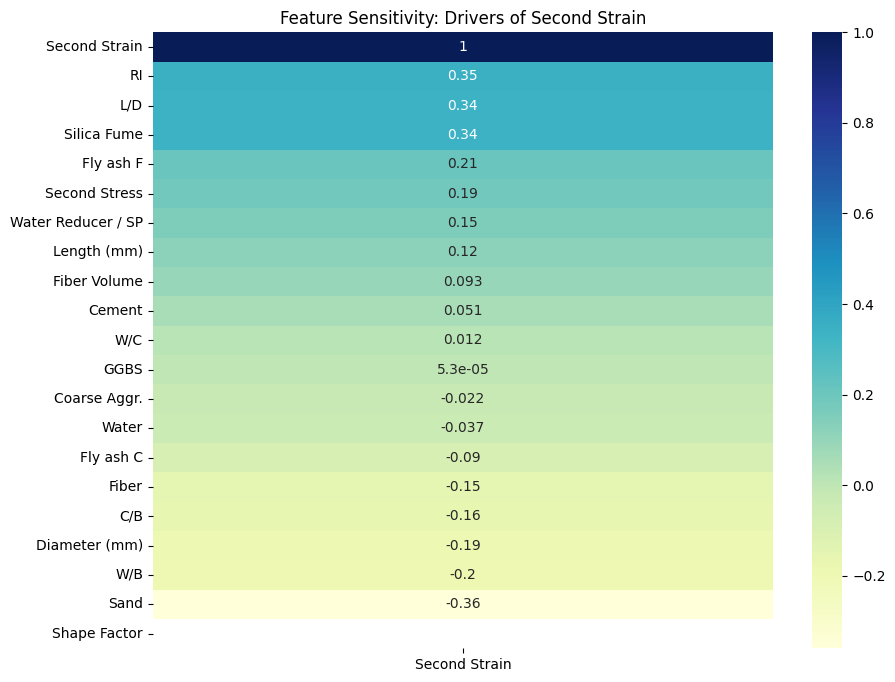

In [ ]:
plt.figure(figsize=(10, 8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix[[target_col]].sort_values(by=target_col, ascending=False),
            annot=True, cmap='YlGnBu')

plt.title(f'Feature Sensitivity: Drivers of {target_col}')
plt.show()

Stable Ensemble Performance: R² = 0.61


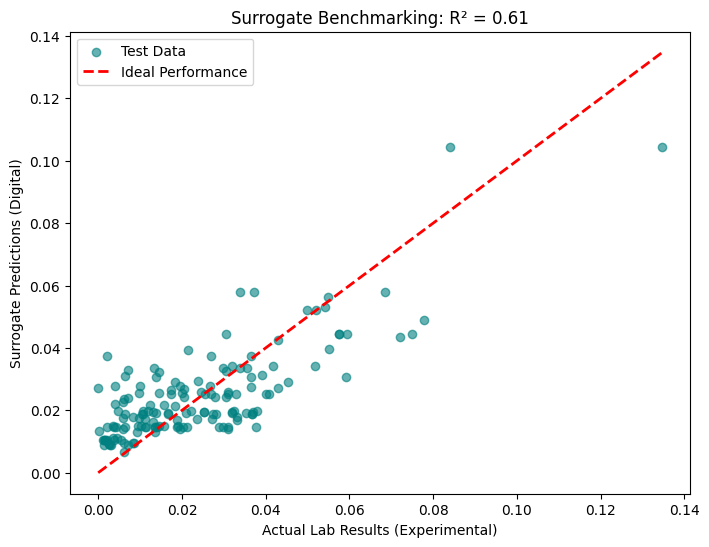

In [ ]:

X = df.select_dtypes(include=[np.number]).drop([target_col], axis=1)
X = X.drop(columns=[c for c in ['Second Stress (MPa)', 'Second Stress'] if c in X.columns])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

import xgboost as xgb

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
import xgboost as xgb
from sklearn.ensemble import VotingRegressor
import xgboost as xgb


rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
xgb_mod = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)


voting_model = VotingRegressor(estimators=[('rf', rf), ('xgb', xgb_mod)])

voting_model.fit(X_train, y_train)
preds = voting_model.predict(X_test)

print(f"Stable Ensemble Performance: R² = {r2_score(y_test, preds):.2f}")
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.6, color='teal', label='Test Data')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal Performance')
plt.xlabel('Actual Lab Results (Experimental)')
plt.ylabel('Surrogate Predictions (Digital)')
plt.title(f'Surrogate Benchmarking: R² = {r2_score(y_test, preds):.2f}')
plt.legend()
plt.show()

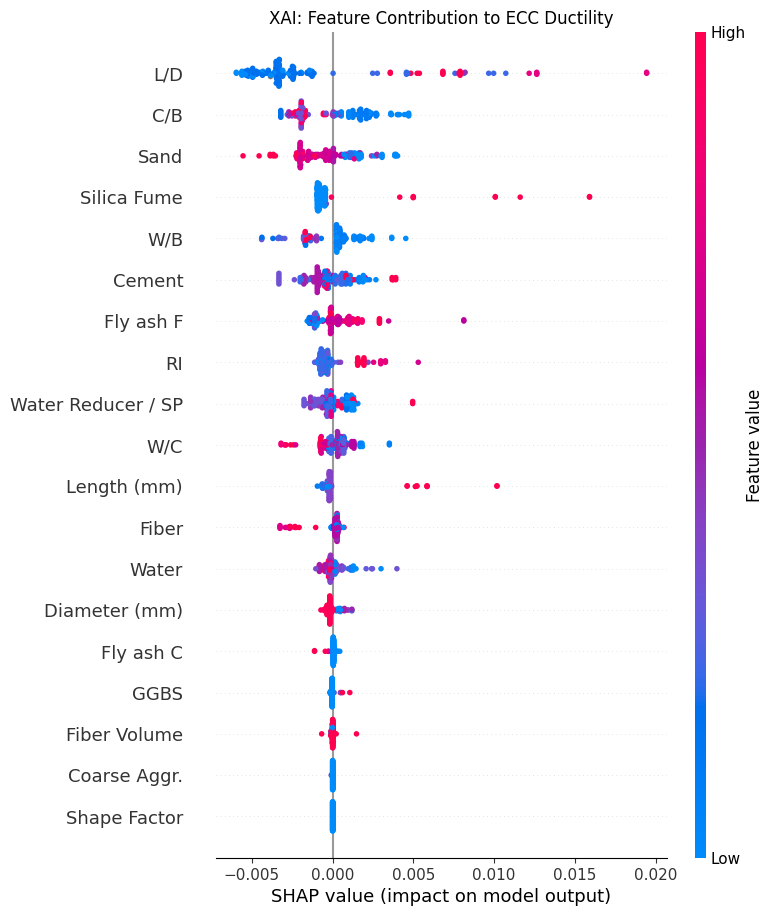

In [ ]:
import shap

explainer = shap.TreeExplainer(voting_model.estimators_[0])
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.title("XAI: Feature Contribution to ECC Ductility")
plt.show()

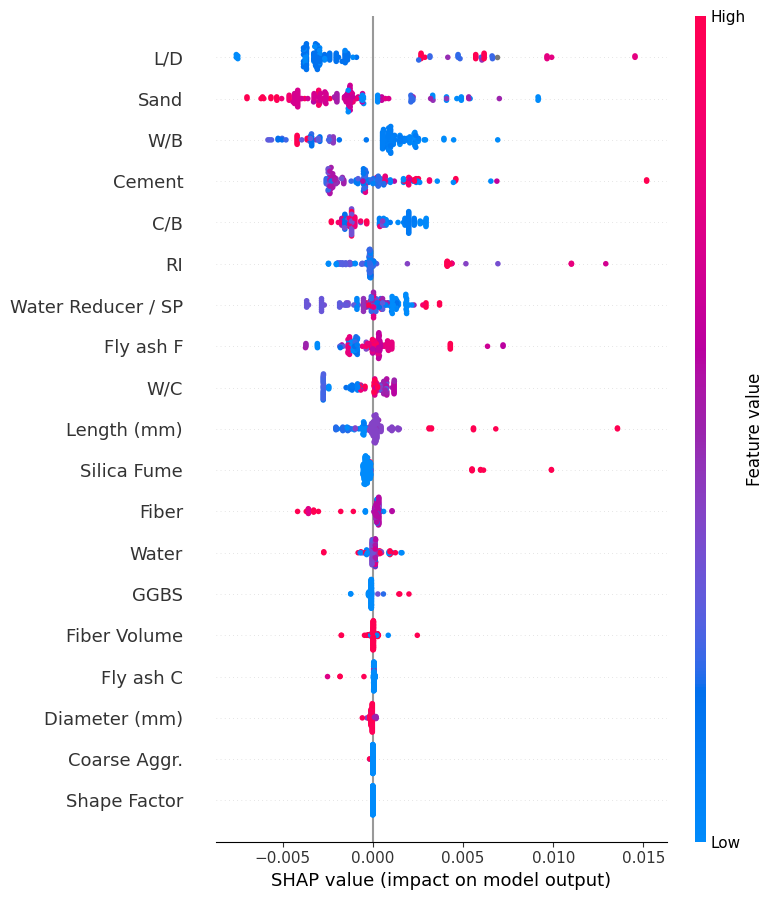

Text(0.5, 1.0, 'XAI: XGBoost Feature Logic')

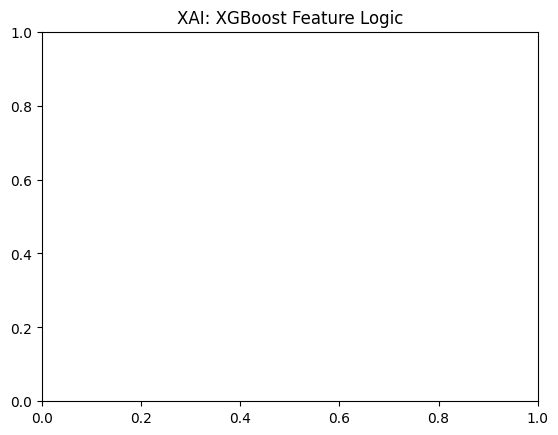

In [ ]:
xgb_explainer = shap.TreeExplainer(voting_model.estimators_[1])
xgb_shap_values = xgb_explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(xgb_shap_values, X_test, feature_names=X.columns)
plt.title("XAI: XGBoost Feature Logic")

In [ ]:
sample_mix = X_test.iloc[0:1].copy()
predicted_val = model.predict(sample_mix)

print(f"System Ready. Predicted Ductility for Candidate Mix: {predicted_val[0]:.2f}%")

System Ready. Predicted Ductility for Candidate Mix: 0.01%


In [ ]:
all_test_preds = model.predict(X_test)

results_comparison = pd.DataFrame({
    'Actual Lab Result': y_test.values,
    'AI Prediction': all_test_preds
})

print("--- TOP 5 DUCTILE MIXES IN TEST SET ---")
print(results_comparison.sort_values(by='AI Prediction', ascending=False).head(5))

--- TOP 5 DUCTILE MIXES IN TEST SET ---
     Actual Lab Result  AI Prediction
23              0.1346       0.109212
9               0.0841       0.109212
84              0.0778       0.069544
55              0.0430       0.059245
118             0.0371       0.057234
